In [1]:
pip install tensorflow opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [5]:
train_dir = r"C:\Users\hp\Documents\Accident detection\dataset\train"
val_dir = r"C:\Users\hp\Documents\Accident detection\dataset\validation"
test_dir = r"C:\Users\hp\Documents\Accident detection\dataset\test"

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images
    batch_size=32,
    class_mode='binary'  # Use 'binary' as it's a binary classification problem (accident vs non-accident)
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.optimizers import Adam

# Try adjusting the learning rate
optimizer = Adam(learning_rate=0.0001)  # You can adjust the learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Continue training with the new learning rate
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5156 - loss: 0.6989 - val_accuracy: 0.5104 - val_loss: 0.6898
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.4375 - loss: 0.7057 - val_accuracy: 0.5104 - val_loss: 0.6896
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5268 - loss: 0.6943 - val_accuracy: 0.5417 - val_loss: 0.6878
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5625 - loss: 0.6796 - val_accuracy: 0.5417 - val_loss: 0.6879
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5261 - loss: 0.6885 - val_accuracy: 0.5208 - val_loss: 0.6869
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5625 - loss: 0.6962 - val_accuracy: 0.5312 - val_loss: 0.6858
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5234 - loss: 0.6878 - val_accuracy: 0.5417 - val_loss: 0.6857
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5312 - loss: 0.7029 - val_accuracy: 0.5417 - val_l

In [23]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - accuracy: 0.5351 - loss: 0.6874
Test accuracy: 0.5199999809265137


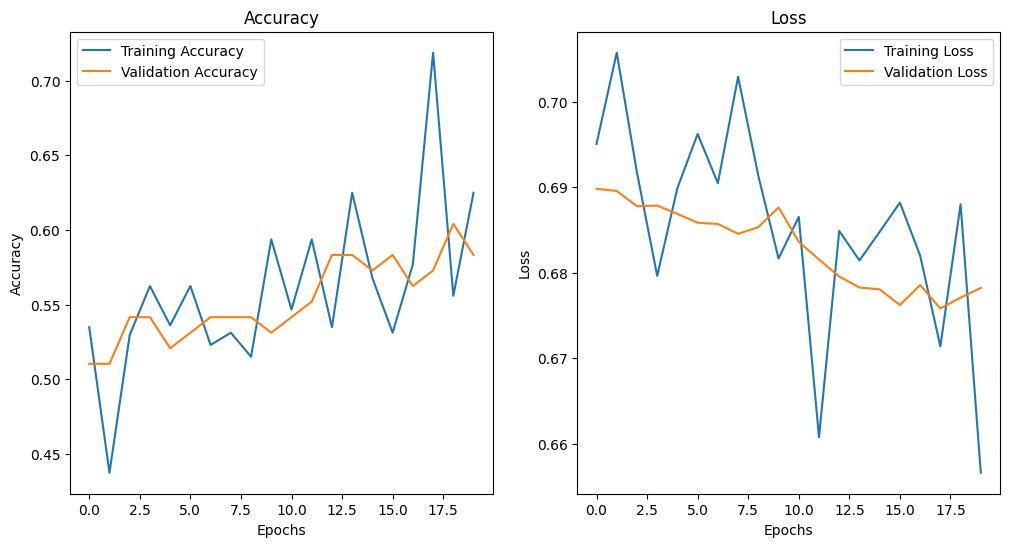

In [25]:
# Plot the training and validation accuracy/loss
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [33]:
model.save('Accident_detection.keras')

In [35]:
from tensorflow.keras.preprocessing import image

# Load an image for prediction
img = image.load_img(r"C:\Users\hp\Downloads\download.jpeg", target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Normalize the image
img_array /= 255.0

# Make the prediction
prediction = model.predict(img_array)
print('No Accident' if prediction[0] > 0.5 else 'Accident')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
No Accident
